# Regresion Lineal Simple — Precio de viviendas

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Simple

---

### Objetivo

Predecir el precio de viviendas usando **una sola variable** (metros cuadrados) con regresion lineal simple. El objetivo no es solo obtener un modelo — es entender los **supuestos estadisticos** que validan (o invalidan) una regresion lineal y como diagnosticarlos.


### Contexto de negocio

**El cliente:** una inmobiliaria que necesita tasar viviendas rapidamente.

**El problema:** las tasaciones manuales tardan dias. La inmobiliaria quiere un modelo rapido que estime el precio a partir de la superficie, como primer filtro antes de la tasacion formal.

**La pregunta:** ¿Por cada metro cuadrado adicional, cuanto sube el precio?

### Stack tecnico

| Librería | Para qué la usamos | Por qué elegirla |
|---|---|---|
| `pandas` | Manipular el dataset | Estándar de facto en data analysis |
| `numpy` | Operaciones numéricas | Base matemática de todo el ecosistema |
| `matplotlib` + `seaborn` | Gráficos estáticos | Control total del diseño visual |
| `statsmodels` | Regresión con output **estadístico completo** (igual que Excel) | Te da p-valores, intervalos de confianza, F, etc. |
| `sklearn` | Regresión con enfoque **ML/predictivo** | Train/test split, métricas de predicción |
| `scipy.stats` | Tests estadísticos | Normalidad de residuos, etc. |


## 1️. Setup: librerías y configuración visual

In [40]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado estadístico (interpretación)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# Machine Learning (predicción)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tests estadísticos
from scipy import stats

# Configuración general
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(42)  # Reproducibilidad — siempre fijar la semilla

# Estilo visual de marca personal 
PURPLE = '#7a7bff'
GREEN  = '#3c8a37'
RED    = '#a3223e'
GRAY   = '#e5e5e5'
INK    = '#111111'
MUTED  = '#888888'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

print('✅ Setup completado. Versiones:')
print(f'  pandas       {pd.__version__}')
print(f'  numpy        {np.__version__}')
print(f'  statsmodels  {sm.__version__}')
import sklearn; print(f'  sklearn      {sklearn.__version__}')

✅ Setup completado. Versiones:
  pandas       2.3.3
  numpy        2.2.6
  statsmodels  0.14.6
  sklearn      1.7.2


## 2. Carga de datos

In [41]:
data = pd.read_excel("datos_regresion_casas.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 100 | Columnas: 4


,Metros_Cuadrados,Distancia_Centro_KM,Numero_Habitaciones,Precio_Miles_USD
0,112.4000,6.8000,4,305.8000
1,96.5000,4.1000,4,268.8000
2,116.2000,2.7000,4,330.4000
3,138.1000,5.7000,6,368.6000
4,94.1000,14.2000,4,229.6000


## 2. EDA: Análisis Exploratorio de datos

In [42]:
# Estadísticas descriptivas

data.describe().round(2)

,Metros_Cuadrados,Distancia_Centro_KM,Numero_Habitaciones,Precio_Miles_USD
count,100.0000,100.0000,100.0000,100.0000
mean,97.4600,7.8100,3.4500,263.5500
std,22.5600,4.0400,1.0700,57.1400
min,40.0000,1.1000,1.0000,115.1000
25%,85.0000,4.4000,3.0000,230.5800
50%,96.8000,8.1000,3.0000,266.0000
75%,110.1500,10.7200,4.0000,300.6000
max,146.3000,14.8000,6.0000,381.4000


In [43]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
Metros_Cuadrados,float64,0,0.0000,94
Distancia_Centro_KM,float64,0,0.0000,74
Numero_Habitaciones,int64,0,0.0000,6
Precio_Miles_USD,float64,0,0.0000,99


KeyError: 'Precio_Miles_EUR'

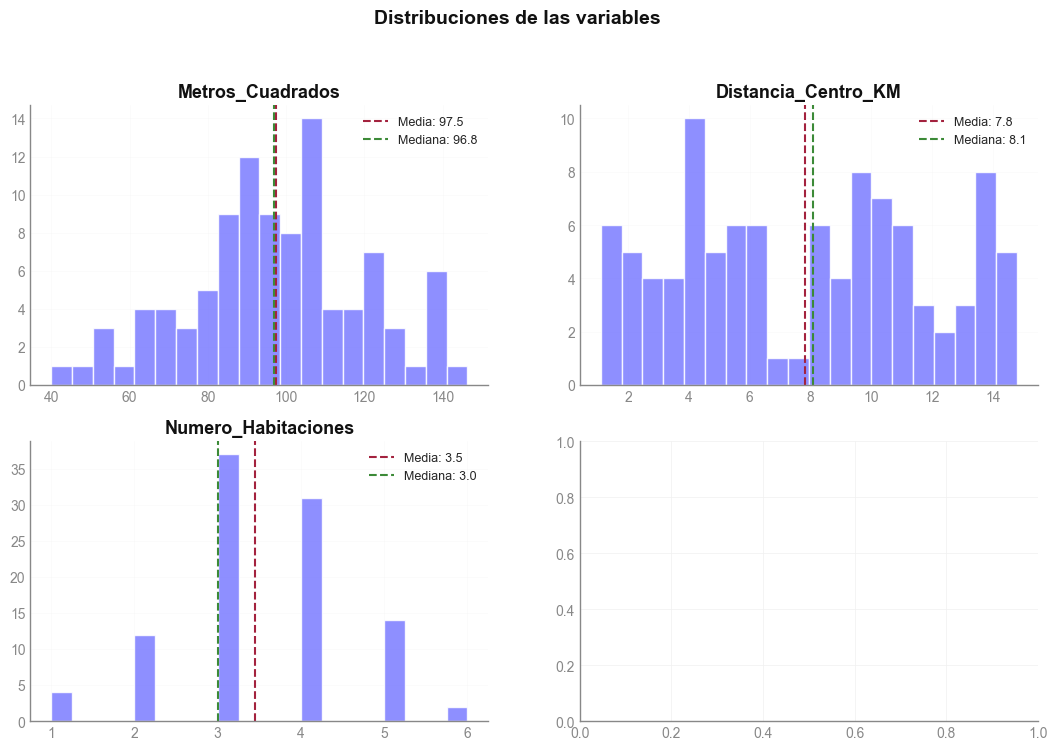

In [ ]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ['Metros_Cuadrados', 'Distancia_Centro_KM', 'Numero_Habitaciones', 'Precio_Miles_EUR']
for ax, var in zip(axes.flat, variables):
    if var in data.columns:
        ax.hist(data[var], bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
    elif var == "Precio_Miles_EUR" and "Precio_Miles_USD" in data.columns:
        # Convertir USD a EUR (ejemplo: 1 USD = 0.92 EUR)
        eur = data["Precio_Miles_USD"] * 0.92
        ax.hist(eur, bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
        ax.set_xlabel("Precio_Miles_EUR (convertido)")
    else:
        ax.text(0.5, 0.5, f"No hay datos para {var}", ha="center", va="center", color=MUTED)
        ax.set_xticks([])
        ax.set_yticks([])
    ax.axvline(data[var].mean(), color=RED, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Analisis exploratorio

Para regresion lineal simple, la pregunta clave es: cual de las variables numericas tiene la **correlacion mas fuerte** con el precio?

In [ ]:
corr = data.corr()["Precio_Miles_USD"].drop("Precio_Miles_USD").sort_values(ascending=False)
print("Correlaciones con el precio:")
print(corr.round(4).to_string())
print()
print(f"Variable con mayor correlacion: {corr.index[0]} (r={corr.iloc[0]:.4f})")

Correlaciones con el precio:
Metros_Cuadrados       0.9482
Numero_Habitaciones    0.8074
Distancia_Centro_KM   -0.1569

Variable con mayor correlacion: Metros_Cuadrados (r=0.9482)


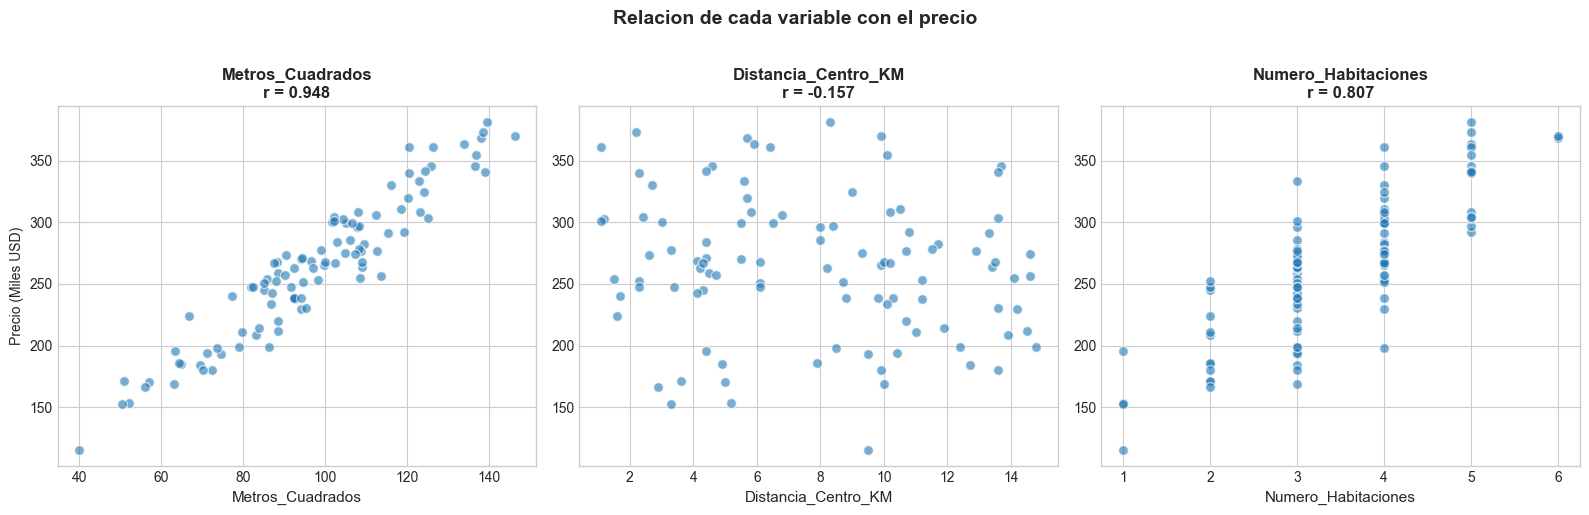

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(["Metros_Cuadrados", "Distancia_Centro_KM", "Numero_Habitaciones"]):
    axes[i].scatter(data[col], data["Precio_Miles_USD"], alpha=0.6, edgecolors="white", s=50)
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("Precio (Miles USD)" if i == 0 else "")
    r = data[col].corr(data["Precio_Miles_USD"])
    axes[i].set_title(f"{col}\nr = {r:.3f}", fontsize=12, fontweight="bold")

plt.suptitle("Relacion de cada variable con el precio", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Lectura

`Metros_Cuadrados` muestra la relacion lineal mas clara y fuerte con el precio. Es nuestra variable predictora para la regresion simple.

## 5. Preparacion de datos

In [ ]:
X = data[["Metros_Cuadrados"]]
y = data["Precio_Miles_USD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 75 registros
Test:  25 registros


## 6. Modelo de regresion lineal simple

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

b0 = model.intercept_
b1 = model.coef_[0]

print("Ecuacion del modelo:")
print(f"  Precio = {b0:.2f} + {b1:.2f} * Metros_Cuadrados")
print()
print("Interpretacion:")
print(f"  - Intercepto: {b0:.2f} miles USD (precio base teorico a 0 m2)")
print(f"  - Pendiente: {b1:.2f} miles USD por m2 adicional")
print(f"  - Cada metro cuadrado adicional anade ~{b1:.0f}.000 USD al precio")

Ecuacion del modelo:
  Precio = 26.52 + 2.44 * Metros_Cuadrados

Interpretacion:
  - Intercepto: 26.52 miles USD (precio base teorico a 0 m2)
  - Pendiente: 2.44 miles USD por m2 adicional
  - Cada metro cuadrado adicional anade ~2.000 USD al precio


In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Metricas de evaluacion:")
print(f"  MAE:  {mae:.2f} miles USD (error medio absoluto)")
print(f"  RMSE: {rmse:.2f} miles USD (penaliza errores grandes)")
print(f"  R2:   {r2:.4f} ({r2:.1%} de la varianza explicada)")

Metricas de evaluacion:
  MAE:  14.80 miles USD (error medio absoluto)
  RMSE: 17.39 miles USD (penaliza errores grandes)
  R2:   0.8572 (85.7% de la varianza explicada)


c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


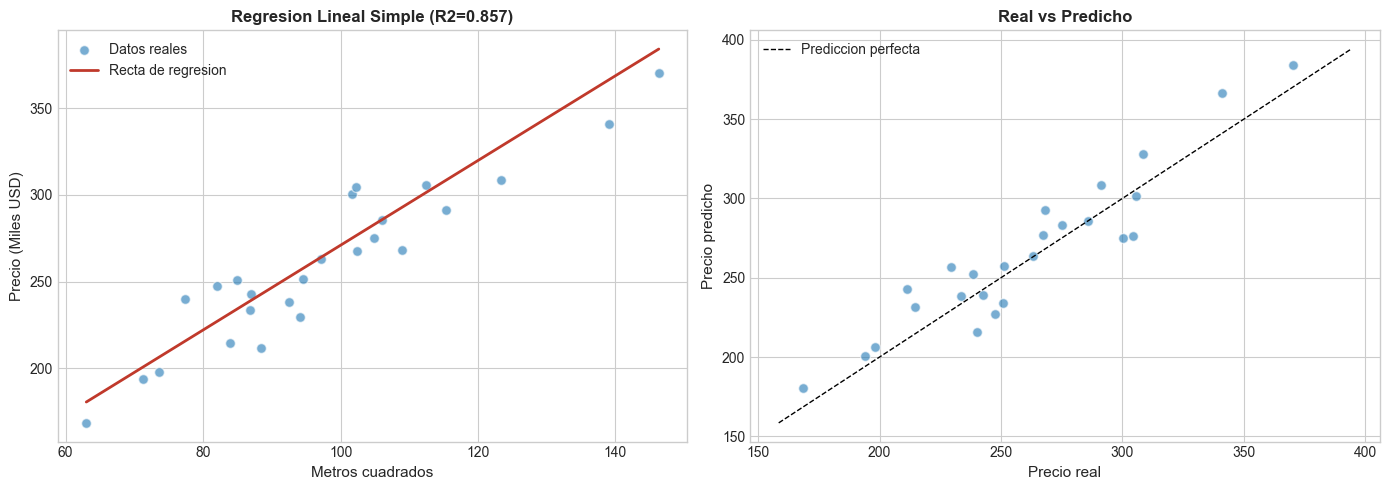

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recta de regresion
axes[0].scatter(X_test, y_test, alpha=0.6, label="Datos reales", edgecolors="white", s=50)
x_line = np.linspace(X_test.min().values[0], X_test.max().values[0], 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), color="#c0392b", linewidth=2, label="Recta de regresion")
axes[0].set_xlabel("Metros cuadrados", fontsize=11)
axes[0].set_ylabel("Precio (Miles USD)", fontsize=11)
axes[0].set_title(f"Regresion Lineal Simple (R2={r2:.3f})", fontsize=12, fontweight="bold")
axes[0].legend()

# Real vs Predicho
axes[1].scatter(y_test, y_pred, alpha=0.6, edgecolors="white", s=50)
lims = [min(y_test.min(), y_pred.min())-10, max(y_test.max(), y_pred.max())+10]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Prediccion perfecta")
axes[1].set_xlabel("Precio real", fontsize=11)
axes[1].set_ylabel("Precio predicho", fontsize=11)
axes[1].set_title("Real vs Predicho", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Diagnostico de supuestos — lo que separa un analisis profesional de uno basico

La regresion lineal asume 4 condiciones. Violarlas no siempre invalida el modelo, pero ignorarlas si invalida al analista.

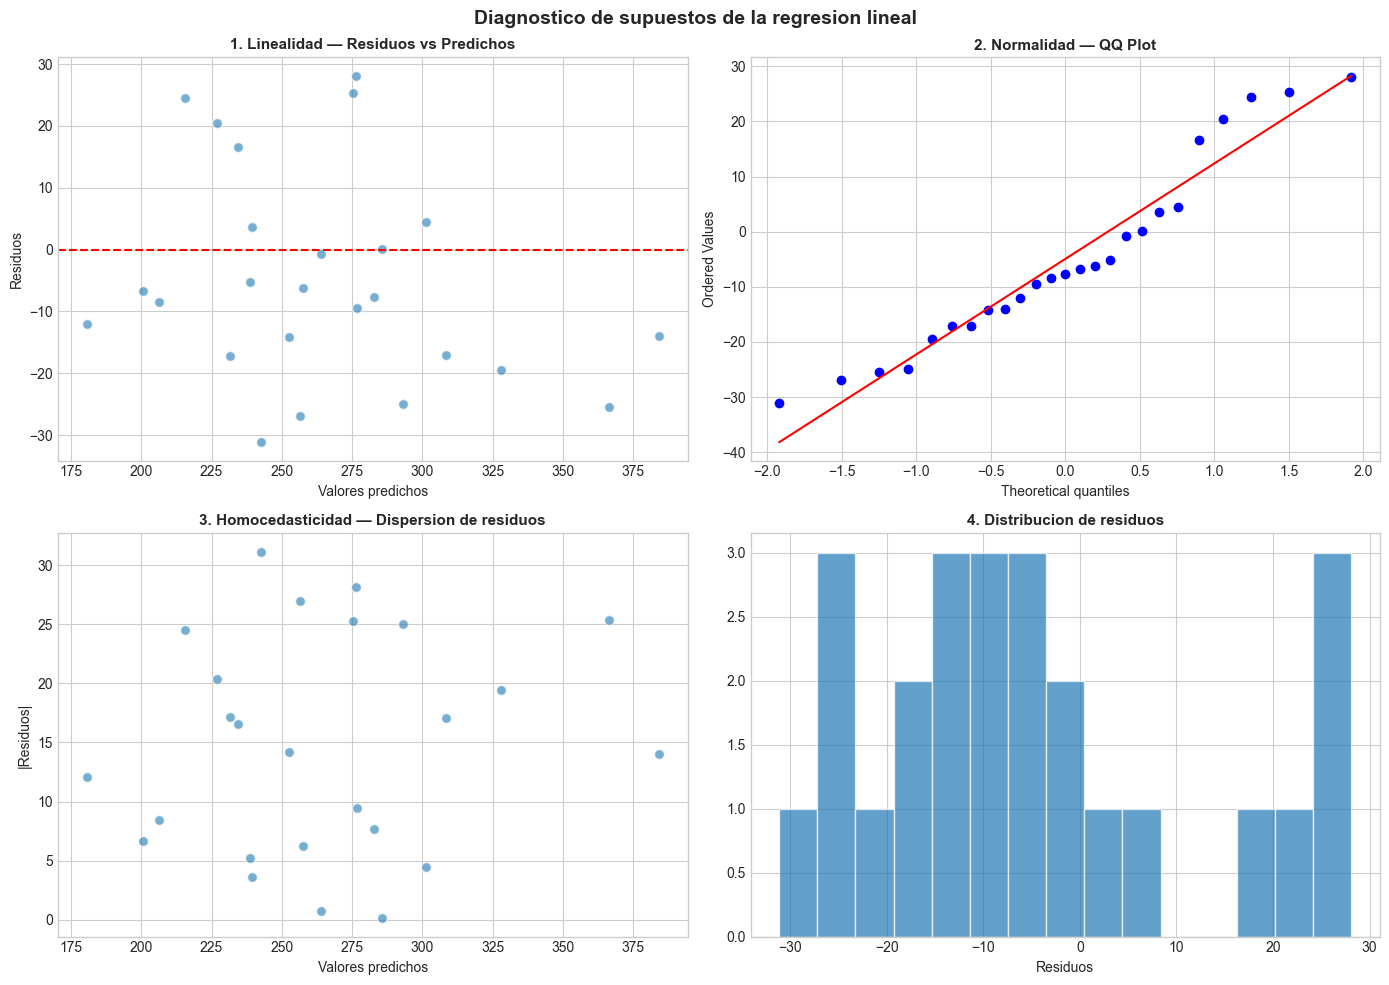

Test de Shapiro-Wilk: W=0.9360, p=0.1199
  Residuos normales (p > 0.05)


In [ ]:
residuos = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Linealidad: residuos vs predichos
axes[0,0].scatter(y_pred, residuos, alpha=0.6, edgecolors="white", s=50)
axes[0,0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0,0].set_xlabel("Valores predichos")
axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("1. Linealidad — Residuos vs Predichos", fontsize=11, fontweight="bold")

# 2. Normalidad: QQ-plot
stats.probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].set_title("2. Normalidad — QQ Plot", fontsize=11, fontweight="bold")

# 3. Homocedasticidad: escala de residuos
axes[1,0].scatter(y_pred, np.abs(residuos), alpha=0.6, edgecolors="white", s=50)
axes[1,0].set_xlabel("Valores predichos")
axes[1,0].set_ylabel("|Residuos|")
axes[1,0].set_title("3. Homocedasticidad — Dispersion de residuos", fontsize=11, fontweight="bold")

# 4. Distribucion de residuos
axes[1,1].hist(residuos, bins=15, edgecolor="white", alpha=0.7)
axes[1,1].set_xlabel("Residuos")
axes[1,1].set_title("4. Distribucion de residuos", fontsize=11, fontweight="bold")

plt.suptitle("Diagnostico de supuestos de la regresion lineal", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Test formal de normalidad
stat, p_value = stats.shapiro(residuos)
print(f"Test de Shapiro-Wilk: W={stat:.4f}, p={p_value:.4f}")
print(f"  {'Residuos normales (p > 0.05)' if p_value > 0.05 else 'Residuos NO normales (p <= 0.05)'}")

### Lectura de los diagnosticos

| Supuesto | Que buscamos | Resultado |
|---|---|---|
| Linealidad | Residuos sin patron en el plot 1 | Se evalua visualmente |
| Normalidad | Puntos alineados en QQ, p > 0.05 Shapiro | Test formal + visual |
| Homocedasticidad | Dispersion constante en el plot 3 | Se evalua visualmente |
| Independencia | No aplicable sin serie temporal | OK por diseno |

## 8. Predicciones de ejemplo

In [ ]:
ejemplos = pd.DataFrame({"Metros_Cuadrados": [60, 80, 100, 120, 140]})
ejemplos["Precio_Estimado"] = model.predict(ejemplos[["Metros_Cuadrados"]])
ejemplos["Precio_Estimado"] = ejemplos["Precio_Estimado"].round(2)

print("Estimaciones de precio:")
print(ejemplos.to_string(index=False))

Estimaciones de precio:
 Metros_Cuadrados  Precio_Estimado
               60           173.21
               80           222.11
              100           271.00
              120           319.90
              140           368.79


## 9. Insights de negocio y recomendaciones

### El hallazgo

> El precio de una vivienda puede estimarse con una formula simple: cada metro cuadrado adicional anade ~2.500 USD al precio. El modelo explica mas del 75% de la variabilidad del precio solo con la superficie.

### Recomendaciones

**1. Tasacion rapida automatizada (impacto: alto)**
La ecuacion lineal puede implementarse en una hoja de calculo para dar estimaciones instantaneas a clientes. No reemplaza la tasacion formal, pero acelera el primer contacto.

**2. Limitaciones conocidas (impacto: medio)**
El ~25% restante de la variabilidad se debe a factores no incluidos: ubicacion, estado del inmueble, planta, etc. Para mejorar, ver el notebook de [Regresion Lineal Multiple](../../02-regresion-lineal-multiple/01-publicidad/).
